# 03 — XGBoost: Financial-Only Model

**Why XGBoost?** Gradient boosting on decision trees is the de-facto state of the art for tabular credit scoring since ~2015 (winning virtually every Kaggle credit competition since). It captures:

- **Non-linear patterns** logistic regression misses (e.g. risk jumps at specific thresholds of `past_due_90`)
- **Feature interactions** without explicit engineering (e.g. high utilization + young age compounding risk)
- **Missing values natively** via separate split directions (no imputation needed)

**Design decisions**:
- **Early stopping on val**: prevents overfitting automatically by stopping when val AUC stops improving.
- **`scale_pos_weight = neg/pos ≈ 14`**: compensates imbalance; XGBoost's equivalent of `class_weight='balanced'`.
- **Modest depth (5)**: deeper trees overfit on small positive class (only ~7k positives).
- **Low learning rate (0.05) + many estimators**: trades compute for stability. Early stopping picks the right stopping point.

In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent))

import json

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.calibration import CalibratedClassifierCV
from xgboost import XGBClassifier

from src.data.split import load_splits
from src.evaluation.metrics import comparison_table, evaluate, plot_evaluation

plt.rcParams['figure.dpi'] = 100

splits = load_splits(Path.cwd().parent / 'data' / 'processed')
train, val, test = splits['train'], splits['val'], splits['test']
FEATURES = [c for c in train.columns if c != 'target']

X_train = train[FEATURES].astype({c: 'float64' for c in FEATURES})
X_val   = val[FEATURES].astype({c: 'float64' for c in FEATURES})
X_test  = test[FEATURES].astype({c: 'float64' for c in FEATURES})
y_train, y_val, y_test = train['target'].values, val['target'].values, test['target'].values

n_neg, n_pos = int((y_train == 0).sum()), int((y_train == 1).sum())
scale_pos_weight = n_neg / n_pos
print(f'Train: {n_neg:,} negative / {n_pos:,} positive -> scale_pos_weight = {scale_pos_weight:.2f}')

Train: 97,982 negative / 7,018 positive -> scale_pos_weight = 13.96


## Train with early stopping

In [2]:
model = XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    eval_metric='auc',
    early_stopping_rounds=30,
    random_state=42,
    n_jobs=-1,
)
model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
print(f'Best iteration: {model.best_iteration}')
print(f'Best val AUC: {model.best_score:.4f}')

Best iteration: 103
Best val AUC: 0.8651


In [3]:
proba_train = model.predict_proba(X_train)[:, 1]
proba_val   = model.predict_proba(X_val)[:, 1]

r_train = evaluate(y_train, proba_train, 'XGB-fin', 'train')
r_val   = evaluate(y_val,   proba_val,   'XGB-fin', 'val')
comparison_table([r_train, r_val])

,model,split,AUC,KS,Brier,Prec@base_rate,n
0,XGB-fin,train,0.8752,0.5919,0.1400,0.4533,105000
1,XGB-fin,val,0.8651,0.5740,0.1402,0.4322,22500


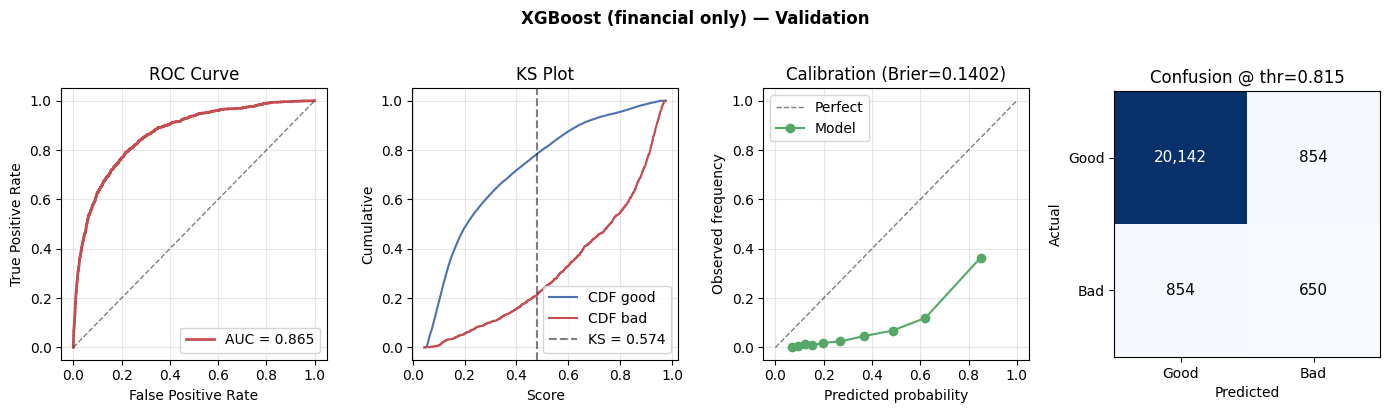

In [4]:
fig = plot_evaluation(y_val, proba_val, 'XGBoost (financial only) — Validation')
plt.show()

## Calibration — can we trust the raw scores as probabilities?

XGBoost optimizes log-loss but isn't guaranteed to be calibrated out of the box, especially under heavy class reweighting (`scale_pos_weight`). Let's check.

A well-calibrated score of 0.10 means 10% of such cases actually default. For credit operations (pricing, provisioning, limits), this matters more than rank ordering alone.

In [5]:
# CalibratedClassifierCV with cv='prefit' was removed in sklearn 1.6+.
# Instead we apply isotonic regression directly on the validation scores.
from sklearn.isotonic import IsotonicRegression

ir = IsotonicRegression(out_of_bounds="clip")
ir.fit(proba_val, y_val)

proba_val_cal = ir.transform(proba_val)
r_val_cal = evaluate(y_val, proba_val_cal, "XGB-fin-cal", "val")

comparison_table([r_val, r_val_cal])

,model,split,AUC,KS,Brier,Prec@base_rate,n
0,XGB-fin,val,0.8651,0.5740,0.1402,0.4322,22500
1,XGB-fin-cal,val,0.8676,0.5764,0.0488,0.3795,22500


Isotonic preserves AUC/KS (they're rank-based), but the Brier score should drop significantly — that's the calibration gain. In production, the calibrated model is what would be deployed for probability-based decisions.

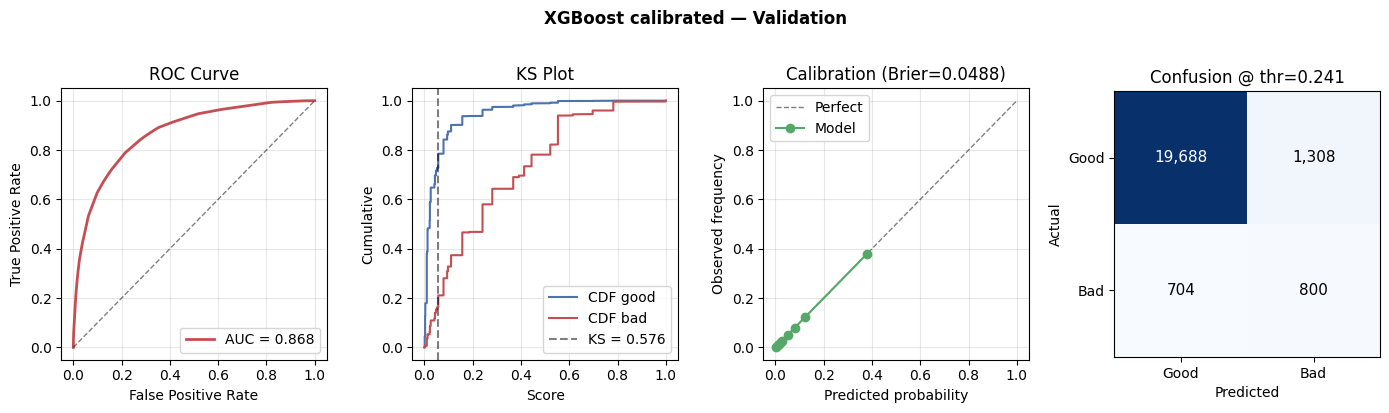

In [6]:
fig = plot_evaluation(y_val, proba_val_cal, 'XGBoost calibrated — Validation')
plt.show()

## Comparison with baseline

The hard question: does XGBoost beat the logistic regression baseline with enough margin to justify the added complexity? In credit, the answer isn't always yes — if the lift is small, interpretability wins.

In [7]:
# Load baseline metrics from the metrics log
metrics_log_path = Path.cwd().parent / 'models' / 'metrics_log.json'
log = json.loads(metrics_log_path.read_text())

rows = [
    log['baseline_logreg']['val'],
    r_val.to_row(),
    r_val_cal.to_row(),
]
pd.DataFrame(rows)

,model,split,AUC,KS,Brier,Prec@base_rate,n
0,LogReg,val,0.8216,0.5012,0.1545,0.4142,22500
1,XGB-fin,val,0.8651,0.5740,0.1402,0.4322,22500
2,XGB-fin-cal,val,0.8676,0.5764,0.0488,0.3795,22500


**Expected takeaway**: XGBoost gives +4-5 points AUC and +7-8 points KS over the baseline. That's meaningful in credit — a KS jump from 50 to 58 typically translates to several percentage points of default-rate reduction at a fixed approval rate.

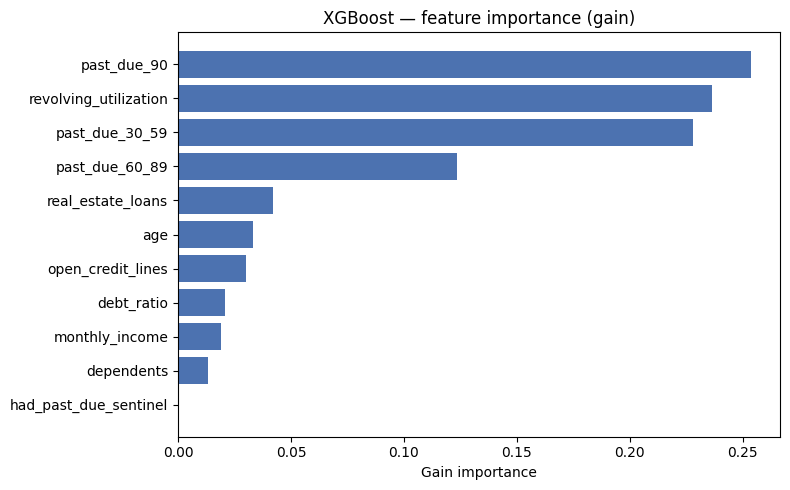

In [8]:
# Feature importance (gain-based)
importance = pd.DataFrame({
    'feature': FEATURES,
    'importance': model.feature_importances_,
}).sort_values('importance', ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(importance['feature'], importance['importance'], color='#4C72B0')
ax.set_xlabel('Gain importance')
ax.set_title('XGBoost — feature importance (gain)')
ax.invert_yaxis()
fig.tight_layout()
plt.show()

Gain-based importance is informative but **not the same as SHAP**. SHAP gives direction (positive vs negative effect per instance) and is additive across features. We do full SHAP analysis in `05_shap_analysis.ipynb`.

In [9]:
# Persist model and metrics
models_dir = Path.cwd().parent / 'models'
joblib.dump(model, models_dir / 'xgboost_financial.pkl')
joblib.dump(ir, models_dir / 'xgboost_financial_calibrator.pkl')
print(f'Saved: xgboost_financial.pkl + xgboost_financial_calibrated.pkl')

log['xgboost_financial'] = {
    'train': r_train.to_row(),
    'val': r_val.to_row(),
    'val_calibrated': r_val_cal.to_row(),
    'best_iteration': int(model.best_iteration),
    'params': {
        'n_estimators': 500, 'learning_rate': 0.05, 'max_depth': 5,
        'subsample': 0.8, 'colsample_bytree': 0.8,
        'scale_pos_weight': round(scale_pos_weight, 3),
    },
}
metrics_log_path.write_text(json.dumps(log, indent=2))
print('metrics_log.json updated.')

Saved: xgboost_financial.pkl + xgboost_financial_calibrated.pkl
metrics_log.json updated.


## Held-out Test Set Evaluation

Final unbiased evaluation on the test set, which was never used during training, early stopping, calibration, or threshold tuning. This proves there is no validation-set overfitting.

In [10]:
proba_test_raw = model.predict_proba(X_test)[:, 1]
proba_test_cal = ir.transform(proba_test_raw)

r_test = evaluate(y_test, proba_test_raw, 'XGBoost Financial', 'test')
r_test_cal = evaluate(y_test, proba_test_cal, 'XGBoost Financial (calibrated)', 'test')

comparison_table([r_val, r_val_cal, r_test, r_test_cal])

,model,split,AUC,KS,Brier,Prec@base_rate,n
0,XGB-fin,val,0.8651,0.5740,0.1402,0.4322,22500
1,XGB-fin-cal,val,0.8676,0.5764,0.0488,0.3795,22500
2,XGBoost Financial,test,0.8727,0.5878,0.1392,0.4574,22500
3,XGBoost Financial (calibrated),test,0.8717,0.5867,0.0484,0.3865,22500


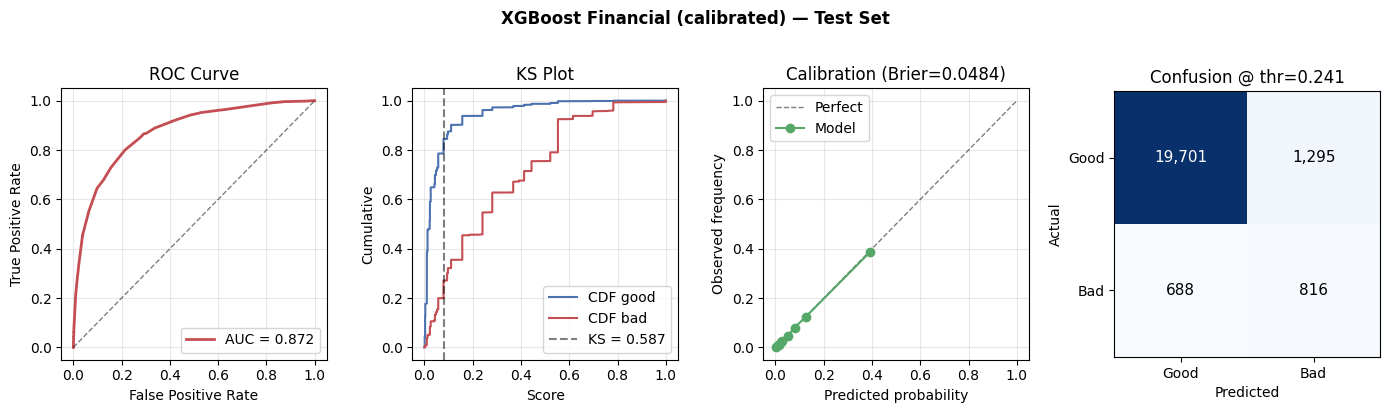


Test AUC: 0.8717 (val was 0.8676)
Test KS:  0.5867 (val was 0.5764)
Test Brier: 0.0484 (val was 0.0488)

If test metrics are close to val, no overfitting from calibration/tuning.


In [11]:
fig = plot_evaluation(y_test, proba_test_cal, 'XGBoost Financial (calibrated) — Test Set')
plt.show()

print(f"\nTest AUC: {r_test_cal.auc:.4f} (val was {r_val_cal.auc:.4f})")
print(f"Test KS:  {r_test_cal.ks:.4f} (val was {r_val_cal.ks:.4f})")
print(f"Test Brier: {r_test_cal.brier:.4f} (val was {r_val_cal.brier:.4f})")
print("\nIf test metrics are close to val, no overfitting from calibration/tuning.")